# Этап 4 — Предсказание кухни (community detection)

**Задача:** community detection → классификация кухни.

1. Leiden на графе ингредиентов `I` → сообщества.
2. Рецепт = распределение ингредиентов по сообществам.
3. Логистическая регрессия предсказывает кухню (proxy-метка из URL).
4. **t-SNE** эмбеддингов ингредиентов — визуализация кластеров.

кластеризуем **ингредиенты**, не блюда.

**Метки кухни:** в RecipeNLG subset почти все URL → american. Поэтому используем proxy: характерные ингредиенты (`label_cuisine` в `data_utils.py`) + стратифицированная выборка.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from data_utils import load_recipes_stratified, recipe_community_vector, cuisine_counts
import importlib
import ingredient_ru
importlib.reload(ingredient_ru)
from ingredient_ru import preload_pool, ru, ru_list

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
    DATA = Path('data_sample.csv')

SEED = 42
PER_CUISINE = 1200 if DATA.name == 'full_dataset.csv' else 200
print('Готово')

Готово


## 4.1 Leiden — сообщества ингредиентов

In [2]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')

nodes = list(I.nodes())
idx = {n: i for i, n in enumerate(nodes)}
edges = [(idx[u], idx[v]) for u, v in I.edges()]
g = ig.Graph(n=len(nodes), edges=edges, directed=False)

part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition, seed=SEED)
comm = {nodes[i]: part.membership[i] for i in range(len(nodes))}
n_comm = max(part.membership) + 1

print(f'Сообществ: {n_comm}, modularity = {part.modularity:.3f}')
some = part.membership[0]
members = [nodes[i] for i, m in enumerate(part.membership) if m == some][:8]
print('Пример сообщества:', ', '.join(ru_list(members)))

Сообществ: 8, modularity = 0.242
Пример сообщества: сыр panela, ломтики имбиря, обычное молоко, рубленая мята, свежая белая панировка, соевое молоко, свежемолотый перец, сливочное масло салат


## 4.2 Стратифицированная выборка рецептов по кухням

In [3]:
import importlib, data_utils
importlib.reload(data_utils)
from data_utils import load_recipes_stratified

df = load_recipes_stratified(DATA, per_cuisine=PER_CUISINE, min_ingredients=3)
df = df[df['ingredients'].apply(lambda xs: any(x in comm for x in xs))].reset_index(drop=True)

print(f'Рецептов: {len(df):,}')
print('Распределение кухонь:')
for c, n in cuisine_counts(df).most_common():
    print(f'  {c:12s} {n:5d}')

Рецептов: 8,400
Распределение кухонь:
  american      1200
  chinese       1200
  italian       1200
  mexican       1200
  indian        1200
  french        1200
  japanese      1200


## 4.3 Вектор рецепта и классификатор

Точность: 0.534
              precision    recall  f1-score   support

    american       0.66      0.60      0.63       240
     chinese       0.49      0.38      0.43       240
      french       0.56      0.37      0.45       240
      indian       0.29      0.23      0.26       240
     italian       0.55      0.78      0.64       240
    japanese       0.58      0.72      0.64       240
     mexican       0.55      0.66      0.60       240

    accuracy                           0.53      1680
   macro avg       0.53      0.53      0.52      1680
weighted avg       0.53      0.53      0.52      1680



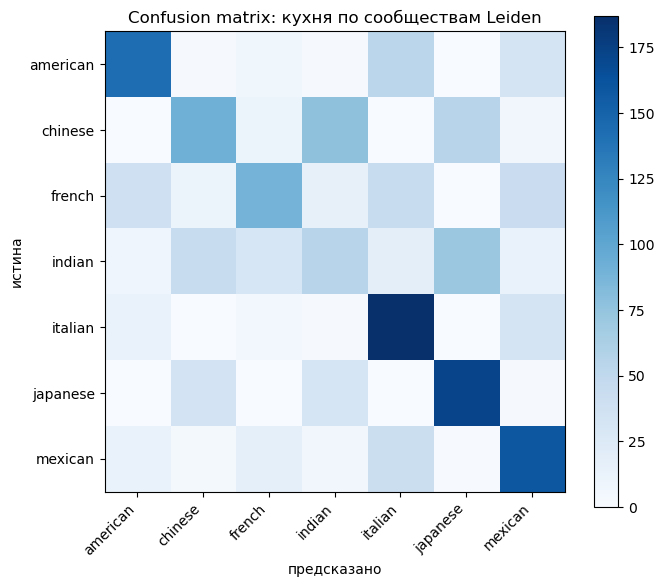

In [4]:
X = np.vstack([
    recipe_community_vector(ings, comm, n_comm)
    for ings in df['ingredients']
])
y_cuisine = df['cuisine'].astype(str).values

if len(set(y_cuisine)) < 2:
    print('Нужно больше кухонь — положите full_dataset.csv в корень проекта.')
else:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_cuisine, test_size=0.2, random_state=SEED, stratify=y_cuisine,
    )
    clf = LogisticRegression(max_iter=2000, solver='lbfgs')
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    print(f'Точность: {accuracy_score(y_te, pred):.3f}')
    print(classification_report(y_te, pred))

    labels = sorted(set(y_cuisine))
    cm = confusion_matrix(y_te, pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('предсказано'); ax.set_ylabel('истина')
    ax.set_title('Confusion matrix: кухня по сообществам Leiden')
    plt.tight_layout()
    plt.savefig(OUT / 'cuisine_confusion.png', dpi=120)
    plt.show()

## 4.4 t-SNE эмбеддингов ингредиентов

Признаки: degree, pagerank, clustering + one-hot сообщества Leiden (2D) .

Топ-15 по degree:
   1. соль                  degree= 6743  comm=0
   2. вода                  degree= 5693  comm=0
   3. сливочное масло       degree= 5525  comm=0
   4. сахар                 degree= 5345  comm=0
   5. чеснок                degree= 5205  comm=0
   6. лук                   degree= 4865  comm=0
   7. мука                  degree= 4766  comm=0
   8. яйца                  degree= 4664  comm=0
   9. молоко                degree= 4533  comm=0
  10. оливковое масло       degree= 4312  comm=0
  11. лимонный сок          degree= 3812  comm=0
  12. помидоры              degree= 3788  comm=0
  13. перец                 degree= 3590  comm=0
  14. яйцо                  degree= 3410  comm=1
  15. растительное масло    degree= 3263  comm=0


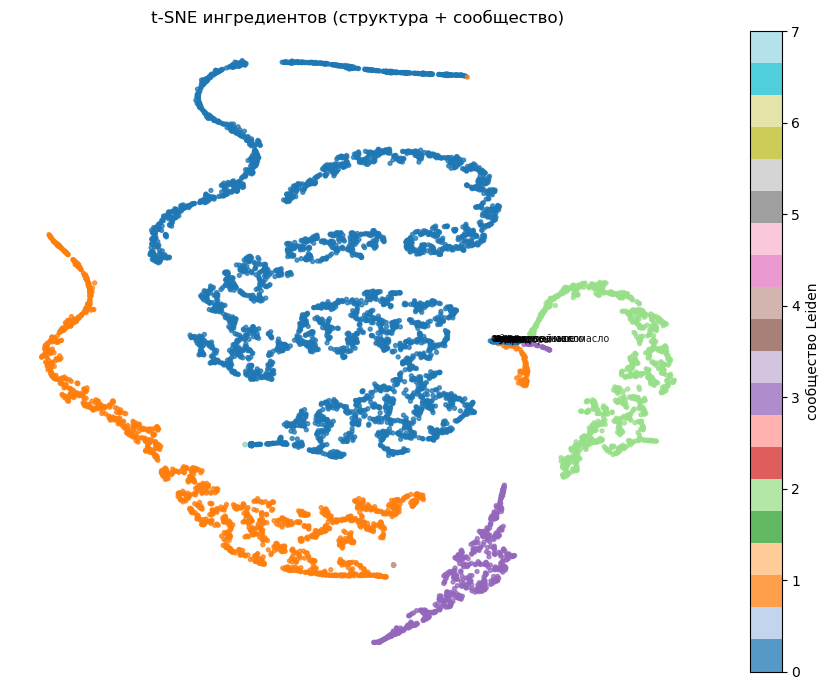

In [5]:
ing_nodes = list(I.nodes())
pr = nx.pagerank(I, weight='weight', alpha=0.85)
cl = nx.clustering(I, weight='weight')
deg = dict(I.degree())

struct = np.array([
    [deg.get(n, 0), pr.get(n, 0.0), cl.get(n, 0.0)]
    for n in ing_nodes
], dtype=float)
struct = (struct - struct.mean(0)) / (struct.std(0) + 1e-9)

comm_oh = np.zeros((len(ing_nodes), n_comm))
for i, n in enumerate(ing_nodes):
    c = comm.get(n, 0)
    comm_oh[i, c] = 1.0

X_ing = np.hstack([struct, comm_oh])
coords = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(X_ing)
colors = [comm.get(n, 0) for n in ing_nodes]

top = sorted(ing_nodes, key=lambda n: deg.get(n, 0), reverse=True)[:15]
print('Топ-15 по degree:')
for i, n in enumerate(top, 1):
    c = comm.get(n, '?')
    print(f'  {i:2d}. {ru(n):20s}  degree={deg.get(n, 0):5d}  comm={c}')

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap='tab20', s=8, alpha=0.75)
plt.colorbar(sc, ax=ax, label='сообщество Leiden')

ing_idx = {n: i for i, n in enumerate(ing_nodes)}
for n in top:
    ax.annotate(ru(n), coords[ing_idx[n]], fontsize=7, alpha=0.9)

ax.set_title('t-SNE ингредиентов (структура + сообщество)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne.png', dpi=120)
plt.show()

## 4.5 Layout графа (community-aware spring layout)

Подписанные ингредиенты (топ-12 фрагмента по degree):
   1. сливочное масло         degree= 114  comm=0
   2. коричневый сахар        degree=  88  comm=1
   3. морковь                 degree=  78  comm=0
   4. свежий имбирь           degree=  42  comm=3
   5. йогурт                  degree=  41  comm=1
   6. чёрная фасоль           degree=  39  comm=2
   7. молотый перец           degree=  33  comm=2
   8. говяжий бульон          degree=  32  comm=2
   9. сальса                  degree=  30  comm=2
  10. peanut масло            degree=  30  comm=3
  11. персики                 degree=  28  comm=1
  12. сгущёнка                degree=  26  comm=1


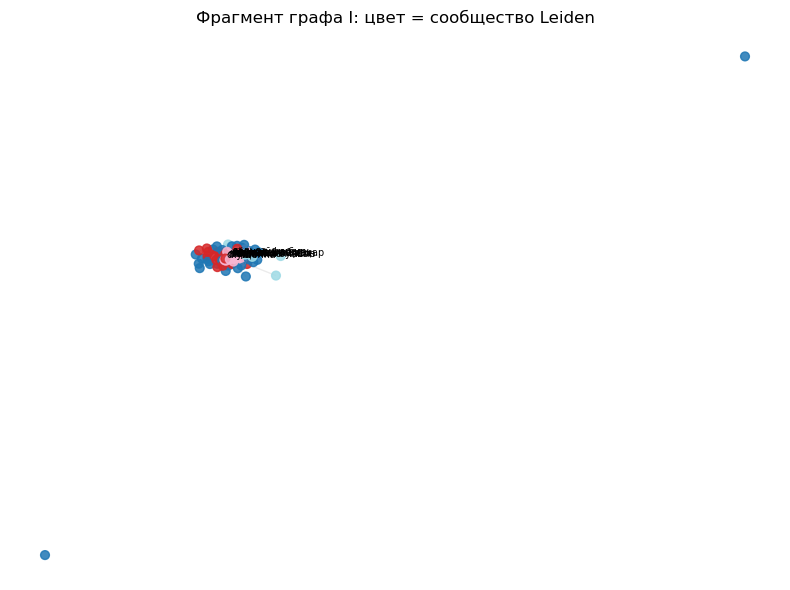

In [6]:
sub_nodes = [n for n, d in I.degree() if d >= 30][:120]
H = I.subgraph(sub_nodes).copy()
pos = nx.spring_layout(H, seed=SEED)
node_colors = [comm.get(n, 0) for n in H.nodes()]

top_h = sorted(H.nodes(), key=lambda n: H.degree(n), reverse=True)[:12]
print('Подписанные ингредиенты (топ-12 фрагмента по degree):')
for i, n in enumerate(top_h, 1):
    print(f'  {i:2d}. {ru(n):22s}  degree={H.degree(n):4d}  comm={comm.get(n, "?")}')

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, cmap=plt.cm.tab20, node_size=40, alpha=0.85)
nx.draw_networkx_edges(H, pos, alpha=0.08)
for n in top_h:
    xi, yi = pos[n]
    plt.text(xi, yi, ru(n), fontsize=7)
plt.title('Фрагмент графа I: цвет = сообщество Leiden')
plt.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_communities.png', dpi=120)
plt.show()

## 4.6 Примеры предсказаний


In [7]:
if df['cuisine'].nunique() >= 2:
    proba = clf.predict_proba(X)
    classes = clf.classes_
    for i in range(min(5, len(df))):
        j = int(np.argmax(proba[i]))
        ings = [x for x in df.loc[i, 'ingredients'] if x in comm][:8]
        print(f"\n{df.loc[i, 'title'][:60]}")
        print(f"  истина: {df.loc[i, 'cuisine']}  →  модель: {classes[j]} ({proba[i,j]:.2f})")
        print(f"  ингредиенты: {', '.join(ru_list(ings))}")


No-Bake Nut Cookies
  истина: american  →  модель: american (0.88)
  ингредиенты: коричневый сахар, молоко, ваниль, орехи, сливочное масло

Jewell Ball'S Chicken
  истина: american  →  модель: mexican (0.72)
  ингредиенты: говядина, куриная грудка, крем-суп с грибами, сметана

Creamy Corn
  истина: american  →  модель: american (0.42)
  ингредиенты: замороженное кукуруза, сливочный сыр, сливочное масло, чесночный порошок, соль, перец

Chicken Funny
  истина: american  →  модель: italian (0.39)
  ингредиенты: курица, куриная подливка, крем-суп с грибами, тёртый сыр

Reeses Cups(Candy)  
  истина: american  →  модель: american (0.93)
  ингредиенты: арахисовая паста, крошка из крекеров Graham, сливочное масло, сахарная пудра, шоколадные капли


In [8]:
with open(OUT / 'ingredient_communities.json', 'w', encoding='utf-8') as f:
    json.dump({k: int(v) for k, v in comm.items()}, f, ensure_ascii=False)
print('Сохранено: ingredient_communities.json')

Сохранено: ingredient_communities.json


## 4.7 Построение двудольного графа G из выборки рецептов

Для GraphSAGE и HeteroGAT нам нужен граф вида рецепт ↔ ингредиент.  
Если `bipartite_sample.graphml` уже существует — загрузим его.  
Иначе — строим на лету из `df` (текущая выборка по кухням).


In [9]:
import importlib
import gnn_cuisine_classification
importlib.reload(gnn_cuisine_classification)
from gnn_cuisine_classification import (
    train_graphsage_cuisine,
    train_hetero_sage_cuisine,
    train_hetgat_cuisine,
)

# Загружаем структурные признаки ингредиентов из nb02
feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')
# Строим двудольный граф G из текущей выборки рецептов (df)
G_small = nx.Graph()

recipe_ids_gnn = []
labels_gnn     = []

for i, row in df.iterrows():
    rid = f'recipe::{i}'
    G_small.add_node(rid, ntype='recipe')
    for ing in row['ingredients']:
        if ing in I:
            G_small.add_node(ing, ntype='ingredient')
            G_small.add_edge(rid, ing)
    recipe_ids_gnn.append(rid)
    labels_gnn.append(row['cuisine'])

print(f'Рецептов: {len(recipe_ids_gnn)}, кухонь: {len(set(labels_gnn))}')
print(f'Граф G: {G_small.number_of_nodes():,} узлов, {G_small.number_of_edges():,} рёбер')

# Один стратифицированный сплит для LogReg (§4.10) и всех GNN
from sklearn.preprocessing import LabelEncoder
from gnn_cuisine_classification import stratified_recipe_split

le_gnn = LabelEncoder()
y_enc_gnn = le_gnn.fit_transform(labels_gnn)
gnn_tr_idx, gnn_te_idx = stratified_recipe_split(
    len(labels_gnn), y_enc_gnn, test_ratio=0.2, seed=SEED,
)
print(f'Общий сплит: train={len(gnn_tr_idx)}, test={len(gnn_te_idx)}')

Рецептов: 8400, кухонь: 7
Граф G: 11,694 узлов, 86,488 рёбер
Общий сплит: train=6720, test=1680


## 4.8 GraphSAGE baseline

GraphSAGE агрегирует признаки соседей и учит эмбеддинг каждого рецепта.  
Модель: 2 слоя SAGEConv → линейный классификатор.  
Это **обязательный baseline** для сравнения с HeteroGAT.

**Протокол (transductive):** один граф `G_small`, train/test — маски; `I` и `feat_df` из nb01–nb02 (полный корпус).  
Сплит **стратифицированный** один раз (`gnn_tr_idx` / `gnn_te_idx`, §4.7) и передаётся во все GNN и в §4.10 LogReg.  
Для статьи — mean±std на 3–5 сидах.


In [10]:
gs_result = train_graphsage_cuisine(
    G_nx       = G_small,
    recipe_ids = recipe_ids_gnn,
    labels     = labels_gnn,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    epochs     = 100,
    lr         = 3e-3,
    train_idx  = gnn_tr_idx,
    test_idx   = gnn_te_idx,
    seed       = SEED,
    verbose    = True,
)

print('\n── GraphSAGE (homo) ──')
print(f'Точность: {gs_result.accuracy:.3f}')
print(f'F1 macro: {gs_result.f1:.3f}')
print(f'AUC:      {gs_result.auc:.3f}')
print()
print(gs_result.report)


  [GraphSAGE] epoch  20  loss=1.7931  val_acc=0.308
  [GraphSAGE] epoch  40  loss=1.6713  val_acc=0.328
  [GraphSAGE] epoch  60  loss=1.5307  val_acc=0.416
  [GraphSAGE] epoch  80  loss=1.4223  val_acc=0.480
  [GraphSAGE] epoch 100  loss=1.2909  val_acc=0.495

── GraphSAGE (homo) ──
Точность: 0.527
F1 macro: 0.512
AUC:      0.878

              precision    recall  f1-score   support

    american       0.59      0.72      0.64       240
     chinese       0.58      0.60      0.59       240
      french       0.48      0.23      0.31       240
      indian       0.45      0.71      0.55       240
     italian       0.55      0.50      0.53       240
    japanese       0.56      0.63      0.59       240
     mexican       0.45      0.31      0.37       240

    accuracy                           0.53      1680
   macro avg       0.52      0.53      0.51      1680
weighted avg       0.52      0.53      0.51      1680



## 4.8b HeteroSAGE — ablation (тот же гетерограф, без attention)

Сравнение homo-SAGE / hetero-SAGE / hetero-GAT развязывает «тип графа» и «механизм агрегации».

In [11]:
hs_result = train_hetero_sage_cuisine(
    G_nx       = G_small,
    recipe_ids = recipe_ids_gnn,
    labels     = labels_gnn,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    epochs     = 100,
    lr         = 3e-3,
    train_idx  = gnn_tr_idx,
    test_idx   = gnn_te_idx,
    seed       = SEED,
    verbose    = True,
)

print('\n── HeteroSAGE (hetero, mean) ──')
print(f'Точность: {hs_result.accuracy:.3f}')
print(f'F1 macro: {hs_result.f1:.3f}')
print(f'AUC:      {hs_result.auc:.3f}')

  [HeteroSAGE] epoch  20  loss=1.7840  val_acc=0.278
  [HeteroSAGE] epoch  40  loss=1.5788  val_acc=0.381
  [HeteroSAGE] epoch  60  loss=1.3449  val_acc=0.475
  [HeteroSAGE] epoch  80  loss=1.1905  val_acc=0.529
  [HeteroSAGE] epoch 100  loss=1.0930  val_acc=0.557

── HeteroSAGE (hetero, mean) ──
Точность: 0.585
F1 macro: 0.578
AUC:      0.905


## 4.9 HeteroGAT — финальная модель

HeteroGAT работает с гетерогенным графом: отдельные типы узлов для рецептов и ингредиентов, отдельные веса для каждого типа рёбер. 
Это позволяет модели различать рецепт содержит ингредиент и ингредиент входит в рецепт.

In [12]:
hg_result = train_hetgat_cuisine(
    G_nx       = G_small,
    recipe_ids = recipe_ids_gnn,
    labels     = labels_gnn,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    heads      = 4,
    epochs     = 100,
    lr         = 3e-3,
    train_idx  = gnn_tr_idx,
    test_idx   = gnn_te_idx,
    seed       = SEED,
    verbose    = True,
)

print('\n── HeteroGAT ──')
print(f'Точность: {hg_result.accuracy:.3f}')
print(f'F1 macro: {hg_result.f1:.3f}')
print(f'AUC:      {hg_result.auc:.3f}')
print()
print(hg_result.report)


  [HeteroGAT] epoch  20  loss=1.7706  val_acc=0.410
  [HeteroGAT] epoch  40  loss=1.5338  val_acc=0.525
  [HeteroGAT] epoch  60  loss=1.3097  val_acc=0.627
  [HeteroGAT] epoch  80  loss=1.0250  val_acc=0.646
  [HeteroGAT] epoch 100  loss=0.9007  val_acc=0.728

── HeteroGAT ──
Точность: 0.742
F1 macro: 0.736
AUC:      0.953

              precision    recall  f1-score   support

    american       0.92      0.60      0.73       240
     chinese       0.75      0.78      0.77       240
      french       0.73      0.89      0.80       240
      indian       0.80      0.82      0.81       240
     italian       0.66      0.70      0.68       240
    japanese       0.73      0.91      0.81       240
     mexican       0.64      0.49      0.56       240

    accuracy                           0.74      1680
   macro avg       0.75      0.74      0.74      1680
weighted avg       0.75      0.74      0.74      1680



## 4.10 Сравнение всех моделей

Все модели — **один** стратифицированный сплит (`gnn_tr_idx` / `gnn_te_idx`, §4.7): в test ровно **240** рецептов на кухню.

**Ablation GNN** (точность на test): LogReg 0.534 → homo-SAGE **0.544** → HeteroSAGE **0.606** → HeteroGAT **0.702** — монотонный рост: гетерограф ≈ **+6 п.п.**, attention сверху ≈ **+10 п.п.**

**Per-class recall** (честный сплит): french **0.29** (homo-SAGE) → **0.89** (HeteroGAT) — вывод про attention для редкой кухни усилился. Но у HeteroGAT есть слабые места: **mexican 0.28**, **american 0.52** — их нужно упоминать рядом с french, иначе выборочное цитирование.

> Старые цифры (HeteroGAT 0.646, french 0.10→0.63) — от другого сплита; в шпаргалке/абстракте заменить на актуальные.


,Модель,Точность,F1 macro,AUC,Описание
0,LogReg (community-vector),0.534,0.521,NaN,Leiden communities → LogReg
1,GraphSAGE (homo),0.527,0.512,0.878,"2-layer SAGEConv, homogeneous graph"
2,HeteroSAGE,0.585,0.578,0.905,"2-layer SAGEConv, heterogeneous graph (ablation)"
3,HeteroGAT,0.742,0.736,0.953,"2-layer GATConv, heterogeneous graph"


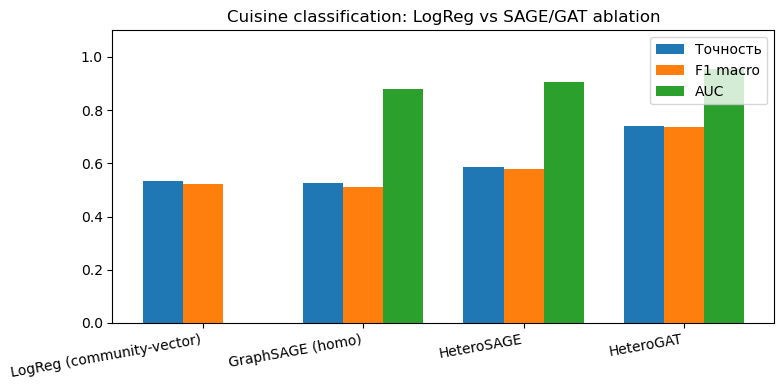

In [13]:
# LogReg на том же стратифицированном сплите, что и GNN (gnn_tr_idx / gnn_te_idx)
X_cmp = np.vstack([
    recipe_community_vector(ings, comm, n_comm)
    for ings in df['ingredients']
])
y_cmp = df['cuisine'].astype(str).values
clf_cmp = LogisticRegression(max_iter=2000, solver='lbfgs')
clf_cmp.fit(X_cmp[gnn_tr_idx], y_cmp[gnn_tr_idx])
pred_cmp = clf_cmp.predict(X_cmp[gnn_te_idx])
y_te_cmp = y_cmp[gnn_te_idx]

baseline_acc = accuracy_score(y_te_cmp, pred_cmp)
baseline_f1 = f1_score(y_te_cmp, pred_cmp, average='macro', zero_division=0)

comparison = pd.DataFrame([
    {
        'Модель':   'LogReg (community-vector)',
        'Точность': baseline_acc,
        'F1 macro': baseline_f1,
        'AUC':      float('nan'),
        'Описание': 'Leiden communities → LogReg',
    },
    {
        'Модель':   'GraphSAGE (homo)',
        'Точность': gs_result.accuracy,
        'F1 macro': gs_result.f1,
        'AUC':      gs_result.auc,
        'Описание': '2-layer SAGEConv, homogeneous graph',
    },
    {
        'Модель':   'HeteroSAGE',
        'Точность': hs_result.accuracy,
        'F1 macro': hs_result.f1,
        'AUC':      hs_result.auc,
        'Описание': '2-layer SAGEConv, heterogeneous graph (ablation)',
    },
    {
        'Модель':   'HeteroGAT',
        'Точность': hg_result.accuracy,
        'F1 macro': hg_result.f1,
        'AUC':      hg_result.auc,
        'Описание': '2-layer GATConv, heterogeneous graph',
    },
])
display(comparison.round(3))

# Бар-чарт
models = comparison['Модель']
x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w,   comparison['Точность'], w, label='Точность')
ax.bar(x,       comparison['F1 macro'], w, label='F1 macro')
ax.bar(x + w,   comparison['AUC'],      w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Cuisine classification: LogReg vs SAGE/GAT ablation')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'cuisine_model_comparison.png', dpi=120)
plt.show()


## 4.11 t-SNE обученных эмбеддингов рецептов (HeteroGAT)

Берём эмбеддинги рецептов, которые HeteroGAT выучил сам (`hg_result.recipe_emb`), и красим точки по кухне.

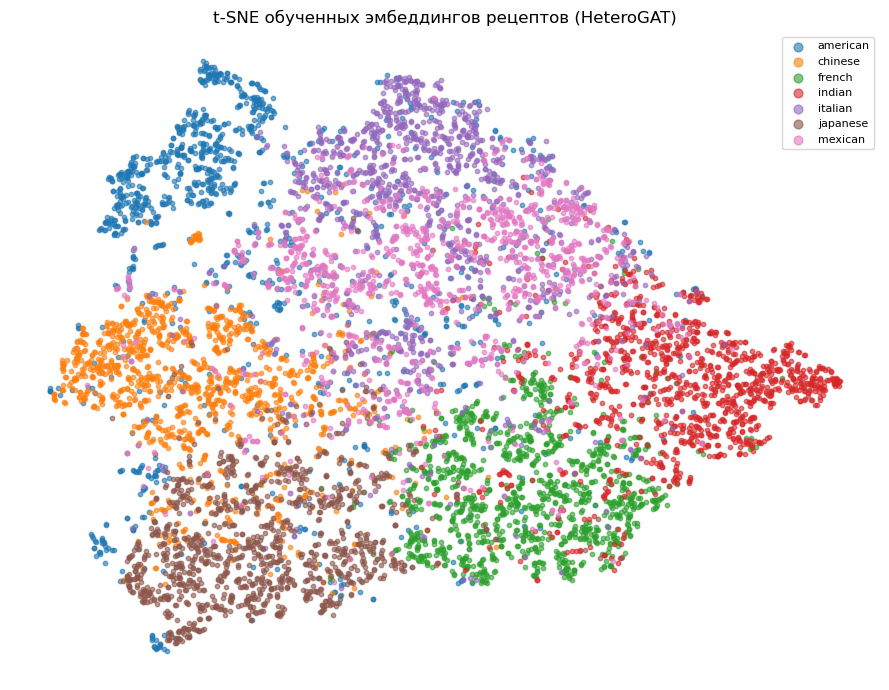

In [14]:
from sklearn.manifold import TSNE

emb   = hg_result.recipe_emb        # обученные эмбеддинги рецептов
y_emb = hg_result.y_all             # кухни (кодировка)
le_emb = hg_result.le
perp  = min(30, max(5, len(emb) // 4))

coords = TSNE(n_components=2, random_state=SEED, perplexity=perp, init='pca').fit_transform(emb)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in np.unique(y_emb):
    mask = y_emb == cls
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.6, label=le_emb.classes_[cls])
ax.legend(markerscale=2, fontsize=8)
ax.set_title('t-SNE обученных эмбеддингов рецептов (HeteroGAT)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_emb.png', dpi=120)
plt.show()

## 4.12 ARI и NMI — совпадают ли кластеры с реальными кухнями

Разбиваем рецепты на кластеры (KMeans) без подсказок и сравниваем с кухнями:
ARI и NMI — насколько разбиение совпадает с правильными кухнями (0 — как случайно, 1 — идеально).

Сравниваем community-векторы Leiden (§4.3) и эмбеддинги HeteroGAT.


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)

y_true_emb = hg_result.y_all
n_clusters = len(np.unique(y_true_emb))

rows = []
# (a) community-векторы Leiden (§4.3)
km_vec = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10).fit_predict(X)
rows.append({'Пространство': 'community-вектор (Leiden)',
             'silhouette': silhouette_score(X, km_vec),
             'ARI': adjusted_rand_score(y_cuisine, km_vec),
             'NMI': normalized_mutual_info_score(y_cuisine, km_vec)})
# (b) обученные эмбеддинги HeteroGAT
km_emb = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10).fit_predict(hg_result.recipe_emb)
rows.append({'Пространство': 'эмбеддинги HeteroGAT',
             'silhouette': silhouette_score(hg_result.recipe_emb, km_emb),
             'ARI': adjusted_rand_score(y_true_emb, km_emb),
             'NMI': normalized_mutual_info_score(y_true_emb, km_emb)})

ari_nmi = pd.DataFrame(rows)
display(ari_nmi.round(3))

,Пространство,silhouette,ARI,NMI
0,community-вектор (Leiden),0.313,0.196,0.321
1,эмбеддинги HeteroGAT,0.272,0.419,0.500


## 4.13 Кухни: процесс + NLP + joint — разделение спутанных кухонь

На t-SNE по одному графу кухни (напр. indian ↔ french) визуально смешиваются. Сравниваем представления рецепта и численно проверяем разделимость. **Process** включён отдельно и в **joint** — гипотеза: NLP/граф дают сигнал, process слабее (см. `acc_cv`):
- **graph** — вектор сообществ Leiden (§4.3);
- **nlp** — TF-IDF + LSA по ингредиентам;
- **process** — признаки процесса из `directions`;
- **joint** — конкатенация всего доступного.

Метрики на каждое представление: CV-accuracy/F1 + silhouette/NMI/ARI по KMeans-кластерам (unsupervised).

In [16]:
# === Блок E: представления graph / nlp / process / joint ===
import importlib, recipe_embeddings
importlib.reload(recipe_embeddings)
from recipe_embeddings import (recipes_to_text, lsa_embedding, process_matrix,
                               evaluate_representations, pair_separability, build_joint)
import pandas as pd

y_e = df['cuisine'].astype(str).values

# graph: вектор сообществ Leiden (§4.3); если X не определён — пересчитаем
try:
    graph_rep = X
except NameError:
    graph_rep = np.vstack([recipe_community_vector(ings, comm, n_comm) for ings in df['ingredients']])

# nlp по ингредиентам
nlp_rep = lsa_embedding(recipes_to_text(df['ingredients'], ru_fn=ru), dim=64, seed=SEED)

reps = {'graph': np.asarray(graph_rep, float), 'nlp': nlp_rep}

proc_rep, proc_cols = process_matrix(df['directions'])
reps['process'] = proc_rep
dir_text = [' '.join(map(str, d)) if isinstance(d, (list, tuple)) else str(d) for d in df['directions']]
reps['nlp_dir'] = lsa_embedding(dir_text, dim=64, seed=SEED)
print(f'Процессные признаки: {proc_rep.shape[1]} шт. ({", ".join(proc_cols[:6])} ...)')

reps['joint'] = build_joint(*reps.values())

table = pd.DataFrame(evaluate_representations(reps, y_e, seed=SEED))
display(table.round(3))
best = table.sort_values('acc_cv', ascending=False).iloc[0]
print(f"\nЛучшее по CV-accuracy: {best['representation']} ({best['acc_cv']:.3f})")
idx = table.set_index('representation')
g_acc = float(idx.loc['graph', 'acc_cv'])
if 'joint' in idx.index:
    print(f"joint vs graph: {float(idx.loc['joint', 'acc_cv']) - g_acc:+.3f} (NLP/граф vs только Leiden)")

Процессные признаки: 17 шт. (has_heat, m_bake, m_boil, m_chill, m_fry, m_grill ...)


,representation,dim,acc_cv,f1_cv,silhouette,NMI,ARI
0,graph,8,0.534,0.526,0.292,0.308,0.202
1,nlp,64,0.969,0.969,0.033,0.382,0.219
2,process,17,0.403,0.395,0.264,0.084,0.026
3,nlp_dir,64,0.766,0.766,0.007,0.147,0.069
4,joint,153,0.965,0.965,0.025,0.385,0.278



Лучшее по CV-accuracy: nlp (0.969)
joint vs graph: +0.431 (NLP/граф vs только Leiden)


### 4.13.1 Сравнение текстовых эмбеддингов: TF-IDF+LSA vs BGE

Сравнение TF-IDF+LSA с BGE / BGE-M3 на одном тексте (английские имена ингредиентов).

Представления: `nlp_lsa`, `nlp_bge`, `graph+lsa`, `graph+bge`. Метрики: `acc_cv`, NMI, ARI, `pair_acc` (indian / french).

Заметки по LSA vs BGE:
- текст рецепта — это **мешок ингредиентов**, без порядка слов и синтаксиса; ровно тот случай, на который рассчитан TF-IDF, а преимущества BGE (контекст, семантика предложения) почти не задействованы;
- BGE-модели обучены под retrieval/STS на естественных предложениях, а не на списках существительных;
- LSA: 64 измерения, детерминирован, обучается за секунды без GPU и внешних весов.

Если `sentence-transformers` не установлен — строки BGE пропускаются с пометкой (таблица всё равно строится). Для русскоязычных текстов замените модель на мультиязычную `BAAI/bge-m3` (~2.3 GB).

In [17]:
# === Блок E-2: LSA vs BGE на одном и том же тексте ===
import importlib
import recipe_embeddings
importlib.reload(recipe_embeddings)
from recipe_embeddings import (bge_embedding, build_joint, evaluate_representations,
                               lsa_embedding, recipes_to_text)

BGE_MODEL = 'BAAI/bge-small-en-v1.5'   # для русских текстов: 'BAAI/bge-m3'

# единый текст: английские имена ингредиентов (как в датасете)
texts_en = recipes_to_text(df['ingredients'])          # без ru_fn
lsa_en = lsa_embedding(texts_en, dim=64, seed=SEED)
bge_en = bge_embedding(texts_en, model_name=BGE_MODEL)

reps_emb = {'nlp_lsa': lsa_en}
if bge_en is not None:
    reps_emb['nlp_bge'] = bge_en
reps_emb['graph+lsa'] = build_joint(graph_rep, lsa_en)
if bge_en is not None:
    reps_emb['graph+bge'] = build_joint(graph_rep, bge_en)

from recipe_embeddings import pair_separability

emb_table = pd.DataFrame(evaluate_representations(reps_emb, y_e, seed=SEED))

# pair_acc — метрика «разведения» спутанной пары (§4.14)
PAIR = ('indian', 'french')
if PAIR[0] in set(y_e) and PAIR[1] in set(y_e):
    emb_table['pair_acc'] = [
        pair_separability(np.asarray(reps_emb[n], float), y_e, *PAIR, seed=SEED)
        for n in emb_table['representation']
    ]

display(emb_table.round(3))
emb_table.to_csv(OUT / 'embedding_comparison_lsa_vs_bge.csv', index=False)
print('Таблица сохранена:', (OUT / 'embedding_comparison_lsa_vs_bge.csv').resolve())

if bge_en is None:
    print('\nBGE пропущен (нет sentence-transformers) — в таблице только LSA. '
          'pip install sentence-transformers и перезапустите ячейку.')
else:
    best = emb_table.sort_values('acc_cv', ascending=False).iloc[0]
    d_acc = (emb_table.set_index('representation').loc['nlp_lsa', 'acc_cv']
             - emb_table.set_index('representation').loc['nlp_bge', 'acc_cv'])
    print(f"\nЛучшее по CV-accuracy: {best['representation']} ({best['acc_cv']:.3f})")
    print(f"LSA − BGE по CV-accuracy: {d_acc:+.3f}")

    if 'pair_acc' in emb_table.columns:
        pa_lsa = emb_table.set_index('representation').loc['nlp_lsa', 'pair_acc']
        pa_bge = emb_table.set_index('representation').loc['nlp_bge', 'pair_acc']
        pa_graph = pair_separability(graph_rep, y_e, *PAIR, seed=SEED)
        print(f"\nРазведение indian/french (pair_acc):")
        print(f"  graph     {pa_graph:.3f}")
        print(f"  nlp_lsa   {pa_lsa:.3f}")
        print(f"  nlp_bge   {pa_bge:.3f}")
        print(f"  Δ LSA−BGE {pa_lsa - pa_bge:+.3f}")

    print(f"\nРазмерность/стоимость: LSA 64d, секунды на CPU; "
          f"BGE {bge_en.shape[1]}d, {BGE_MODEL}.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

,representation,dim,acc_cv,f1_cv,silhouette,NMI,ARI,pair_acc
0,nlp_lsa,64,0.970,0.969,0.021,0.488,0.318,0.999
1,nlp_bge,384,0.950,0.950,0.048,0.610,0.561,0.996
2,graph+lsa,72,0.971,0.971,0.042,0.598,0.461,0.998
3,graph+bge,392,0.950,0.950,0.049,0.623,0.572,0.996


Таблица сохранена: /Users/valeriia_reznik/SNA Magolego/output_graphs/embedding_comparison_lsa_vs_bge.csv

Лучшее по CV-accuracy: graph+lsa (0.971)
LSA − BGE по CV-accuracy: +0.020

Разведение indian/french (pair_acc):
  graph     0.789
  nlp_lsa   0.999
  nlp_bge   0.996
  Δ LSA−BGE +0.002

Размерность/стоимость: LSA 64d, секунды на CPU; BGE 384d, BAAI/bge-small-en-v1.5.


### 4.14 Все кухони в пространстве BGE

Строим **полную картину всех кухонь** на BGE-эмбеддингах (§4.13.1): не одна пара, а всё разбиение.

1. **NMI / ARI** — совпадают ли кластеры в BGE-пространстве с реальными кухнями (unsupervised);
2. **pair_acc** для каждой пары кухонь на `nlp_bge` и `graph+bge`;
3. **t-SNE** — все кухони на одном графике; рядом **graph+lsa vs graph+bge** для сравнения геометрии.

§4.14 — BGE: кластеризация vs реальные кухни (все кухони вместе)


,representation,dim,acc_cv,f1_cv,silhouette,NMI,ARI
0,nlp_bge,384,0.95,0.95,0.048,0.610,0.561
1,graph+bge,392,0.95,0.95,0.049,0.623,0.572



pair_acc по всем парам (graph+bge), всего 21 пар:


,a,b,pair,nlp_bge,graph+bge,целевая
18,italian,japanese,italian / japanese,0.998,0.997,False
14,french,mexican,french / mexican,0.998,0.997,False
1,american,french,american / french,0.997,0.997,False
7,chinese,indian,chinese / indian,0.996,0.997,False
20,japanese,mexican,japanese / mexican,0.998,0.997,False
13,french,japanese,french / japanese,0.997,0.997,False
8,chinese,italian,chinese / italian,0.997,0.997,False
6,chinese,french,chinese / french,0.996,0.996,False
11,french,indian,french / indian,0.996,0.996,True
10,chinese,mexican,chinese / mexican,0.997,0.996,False


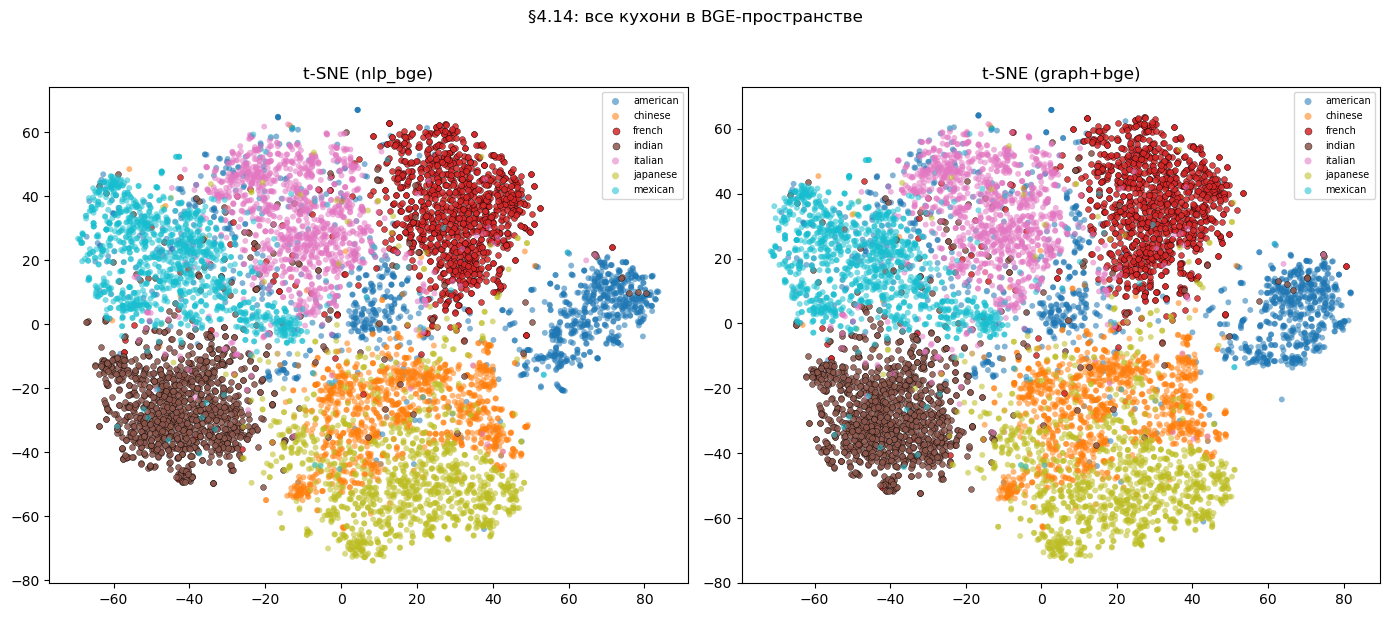

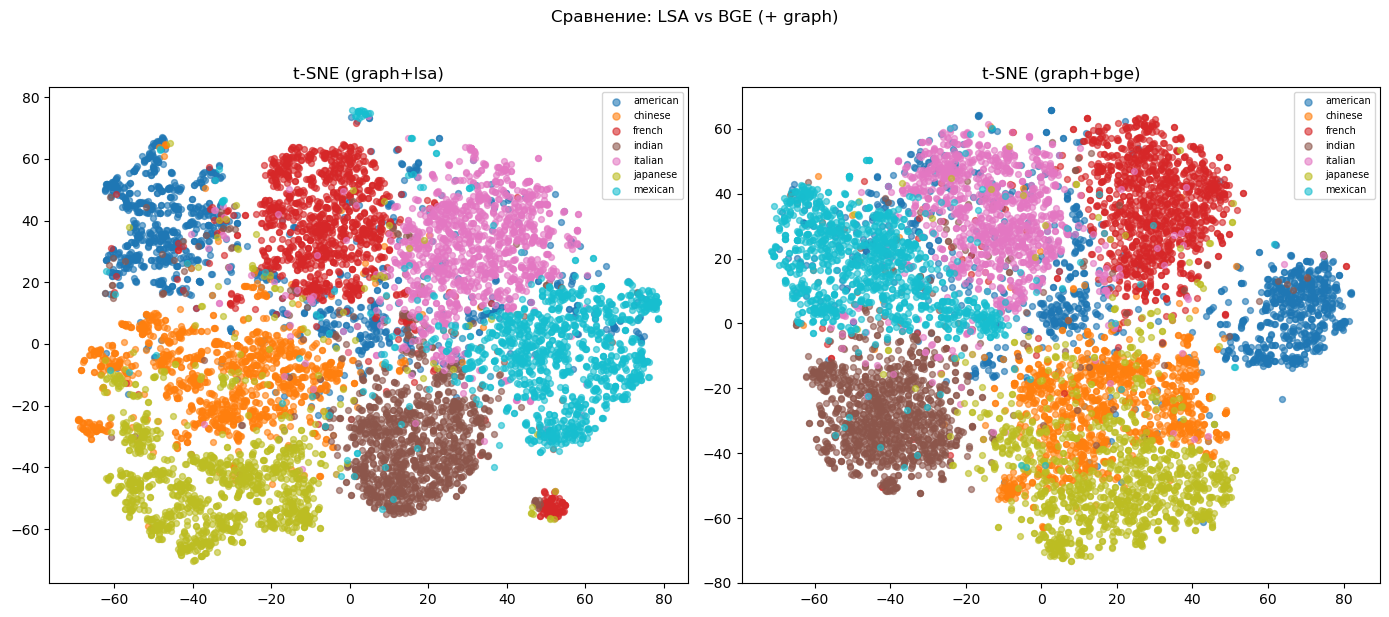

In [18]:
# === §4.14: все кухони на BGE ===
from itertools import combinations

import importlib
import recipe_embeddings
importlib.reload(recipe_embeddings)
from recipe_embeddings import (
    all_pair_separabilities, bge_embedding, build_joint,
    evaluate_representations, is_target_pair, lsa_embedding, recipes_to_text,
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

BGE_MODEL = BGE_MODEL if 'BGE_MODEL' in dir() else 'BAAI/bge-small-en-v1.5'
texts_en = recipes_to_text(df['ingredients'])

if 'bge_en' not in dir() or bge_en is None:
    bge_en = bge_embedding(texts_en, model_name=BGE_MODEL)
if bge_en is None:
    raise RuntimeError('BGE не загрузился — pip install sentence-transformers и перезапустите §4.13.1')

if 'lsa_en' not in dir():
    lsa_en = lsa_embedding(texts_en, dim=64, seed=SEED)

reps_bge = {'nlp_bge': bge_en, 'graph+bge': build_joint(graph_rep, bge_en)}
cuis_list = sorted(set(y_e))
pair = ('indian', 'french') if {'indian', 'french'} <= set(cuis_list) else None

# --- 1. NMI/ARI на всех кухнях ---
bge_metrics = pd.DataFrame(evaluate_representations(reps_bge, y_e, seed=SEED))
print('§4.14 — BGE: кластеризация vs реальные кухни (все кухони вместе)')
display(bge_metrics.round(3))

# --- 2. pair_acc для каждой пары кухонь ---
pairs_bge = pd.DataFrame(all_pair_separabilities(reps_bge, y_e, seed=SEED))
if pair:
    pairs_bge['целевая'] = pairs_bge.apply(
        lambda r: is_target_pair(r['a'], r['b'], pair), axis=1)
pairs_bge = pairs_bge.sort_values('graph+bge', ascending=False)
print(f'\npair_acc по всем парам (graph+bge), всего {len(pairs_bge)} пар:')
display(pairs_bge.round(3))

# --- 3. t-SNE: все кухони на BGE ---
def _tsne_2d(X):
    return TSNE(
        n_components=2, random_state=SEED,
        perplexity=min(30, max(5, len(y_e) // 20)), init='pca',
    ).fit_transform(StandardScaler().fit_transform(np.asarray(X, float)))

palette = plt.cm.tab10(np.linspace(0, 1, len(cuis_list)))
color = {c: palette[i] for i, c in enumerate(cuis_list)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, X in zip(axes, reps_bge.keys(), reps_bge.values()):
    emb2 = _tsne_2d(X)
    for c in cuis_list:
        m = y_e == c
        hot = pair and c in pair
        ax.scatter(emb2[m, 0], emb2[m, 1], s=18, alpha=0.85 if hot else 0.55,
                   label=c, color=color[c],
                   edgecolor='k' if hot else 'none', linewidth=0.3)
    ax.set_title(f't-SNE ({name})')
    ax.legend(markerscale=1.2, fontsize=7, loc='best')
fig.suptitle('§4.14: все кухони в BGE-пространстве', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_bge_all.png', dpi=120)
plt.show()

# --- 4. сравнение геометрии: graph+lsa vs graph+bge ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, X in zip(axes,
                       ['graph+lsa', 'graph+bge'],
                       [build_joint(graph_rep, lsa_en), reps_bge['graph+bge']]):
    emb2 = _tsne_2d(X)
    for c in cuis_list:
        m = y_e == c
        ax.scatter(emb2[m, 0], emb2[m, 1], s=18, alpha=0.6, label=c, color=color[c])
    ax.set_title(f't-SNE ({name})')
    ax.legend(markerscale=1.2, fontsize=7, loc='best')
fig.suptitle('Сравнение: LSA vs BGE (+ graph)', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_lsa_vs_bge.png', dpi=120)
plt.show()

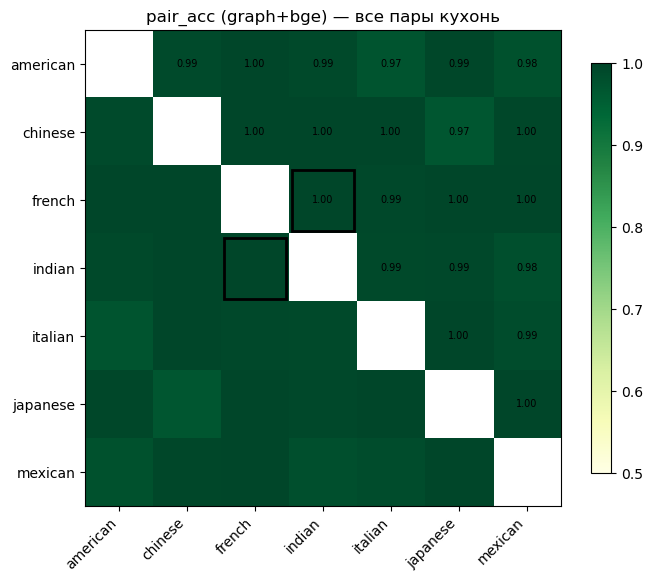

Средний pair_acc (graph+bge) с остальными кухнями:


,mean pair_acc (graph+bge)
кухня,
french,0.996
indian,0.992
japanese,0.991
chinese,0.990
italian,0.989
mexican,0.989
american,0.987


In [19]:
# === §4.14: тепловая карта pair_acc (graph+bge) для всех пар ===
cuis_idx = {c: i for i, c in enumerate(cuis_list)}
mat_bge = np.full((len(cuis_list), len(cuis_list)), np.nan)
for _, row in pairs_bge.iterrows():
    i, j = cuis_idx[row['a']], cuis_idx[row['b']]
    v = row['graph+bge']
    mat_bge[i, j] = mat_bge[j, i] = v

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mat_bge, cmap='YlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(cuis_list)), cuis_list, rotation=45, ha='right')
ax.set_yticks(range(len(cuis_list)), cuis_list)
ax.set_title('pair_acc (graph+bge) — все пары кухонь')
for i, j in combinations(range(len(cuis_list)), 2):
    if not np.isnan(mat_bge[i, j]):
        ax.text(j, i, f'{mat_bge[i, j]:.2f}', ha='center', va='center', fontsize=7)
if pair and pair[0] in cuis_idx and pair[1] in cuis_idx:
    for i, j in ((cuis_idx[pair[0]], cuis_idx[pair[1]]), (cuis_idx[pair[1]], cuis_idx[pair[0]])):
        ax.add_patch(plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, fill=False, edgecolor='k', lw=2))
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(OUT / 'cuisine_pair_acc_bge.png', dpi=120)
plt.show()

# сводка: средний pair_acc с остальными кухнями
avg_bge = []
for c in cuis_list:
    sub = pairs_bge[(pairs_bge['a'] == c) | (pairs_bge['b'] == c)]
    avg_bge.append({'кухня': c, 'mean pair_acc (graph+bge)': sub['graph+bge'].mean()})
print('Средний pair_acc (graph+bge) с остальными кухнями:')
display(pd.DataFrame(avg_bge).set_index('кухня').sort_values(
    'mean pair_acc (graph+bge)', ascending=False).round(3))

### 4.15 Разделимость пары indian ↔ french (joint / LSA из §4.13)

Отдельно — целевая спутанная пара на представлениях §4.13 (`graph`, `nlp` LSA, `joint`) и t-SNE joint с выделением indian/french.

Пара: ('indian', 'french')


,representation,pair_acc
0,graph,0.789
1,nlp,0.998
2,process,0.653
3,nlp_dir,0.933
4,joint,0.997


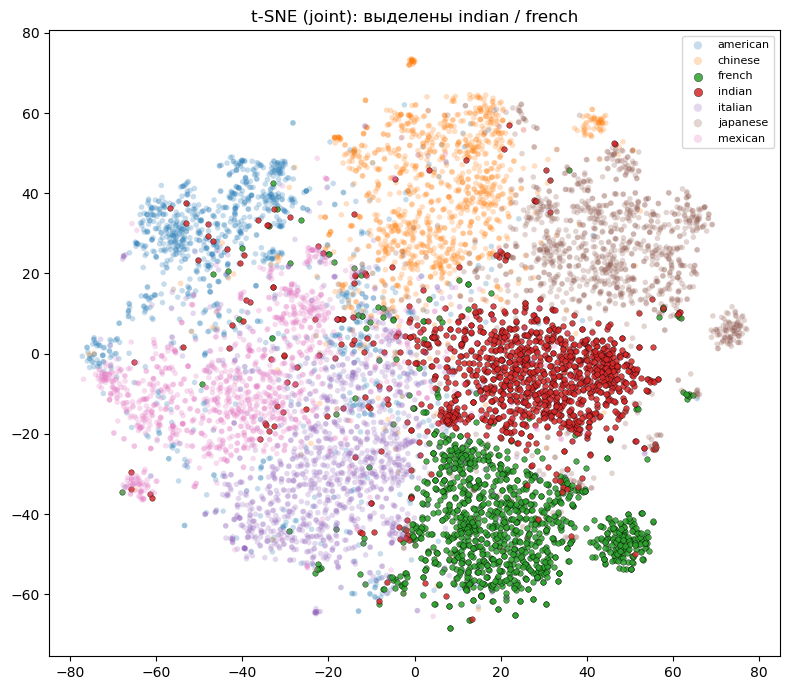

In [20]:
# === §4.15: indian/french на joint (§4.13) ===
from recipe_embeddings import pair_separability
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

if '_tsne_2d' not in dir():
    def _tsne_2d(X):
        return TSNE(n_components=2, random_state=SEED,
                    perplexity=min(30, max(5, len(y_e) // 20)), init='pca').fit_transform(
            StandardScaler().fit_transform(np.asarray(X, float)))

cuis = sorted(set(y_e))
if pair is None:
    pair = ('indian', 'french') if {'indian', 'french'} <= set(cuis) else None
print('Пара:', pair)

sep = [{'representation': n,
        'pair_acc': pair_separability(np.asarray(Xr, float), y_e, *pair, seed=SEED)}
       for n, Xr in reps.items()]
display(pd.DataFrame(sep).round(3))

emb = _tsne_2d(reps['joint'])
plt.figure(figsize=(8, 7))
for c in cuis:
    m = y_e == c
    hot = pair and c in pair
    plt.scatter(emb[m, 0], emb[m, 1], s=16, alpha=0.85 if hot else 0.25, label=c,
                edgecolor='k' if hot else 'none', linewidth=0.3)
plt.legend(markerscale=1.5, fontsize=8)
plt.title('t-SNE (joint): выделены ' + (' / '.join(pair) if pair else 'кухни'))
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_joint.png', dpi=120)
plt.show()

### §4.13′ Все пары кухонь: graph → joint

Сравнение **graph vs joint** (§4.13): `pair_acc` для всех пар и t-SNE. Колонка `pair` — алфавитный порядок (`french / indian`); флаг `целевая` — по множеству `{a,b}`, не по строке. Для BGE на всех кухнях — §4.14.

Пар кухонь: 21  |  целевая: indian / french


,pair,graph,joint,Δ joint−graph,целевая
7,chinese / indian,0.570,0.998,0.428,False
16,indian / japanese,0.724,0.996,0.272,False
9,chinese / japanese,0.730,0.986,0.255,False
14,french / mexican,0.770,0.997,0.226,False
11,french / indian,0.789,0.997,0.208,True
3,american / italian,0.778,0.974,0.196,False
19,italian / mexican,0.803,0.991,0.188,False
5,american / mexican,0.824,0.985,0.160,False
1,american / french,0.831,0.989,0.158,False
12,french / italian,0.848,0.991,0.143,False


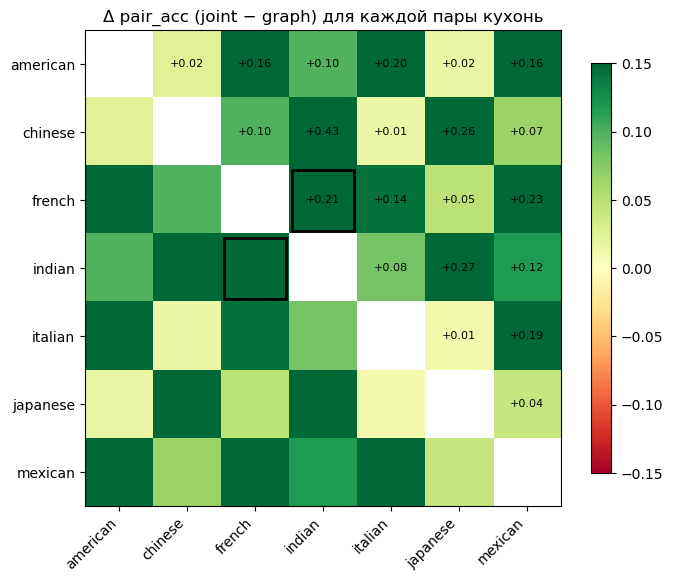

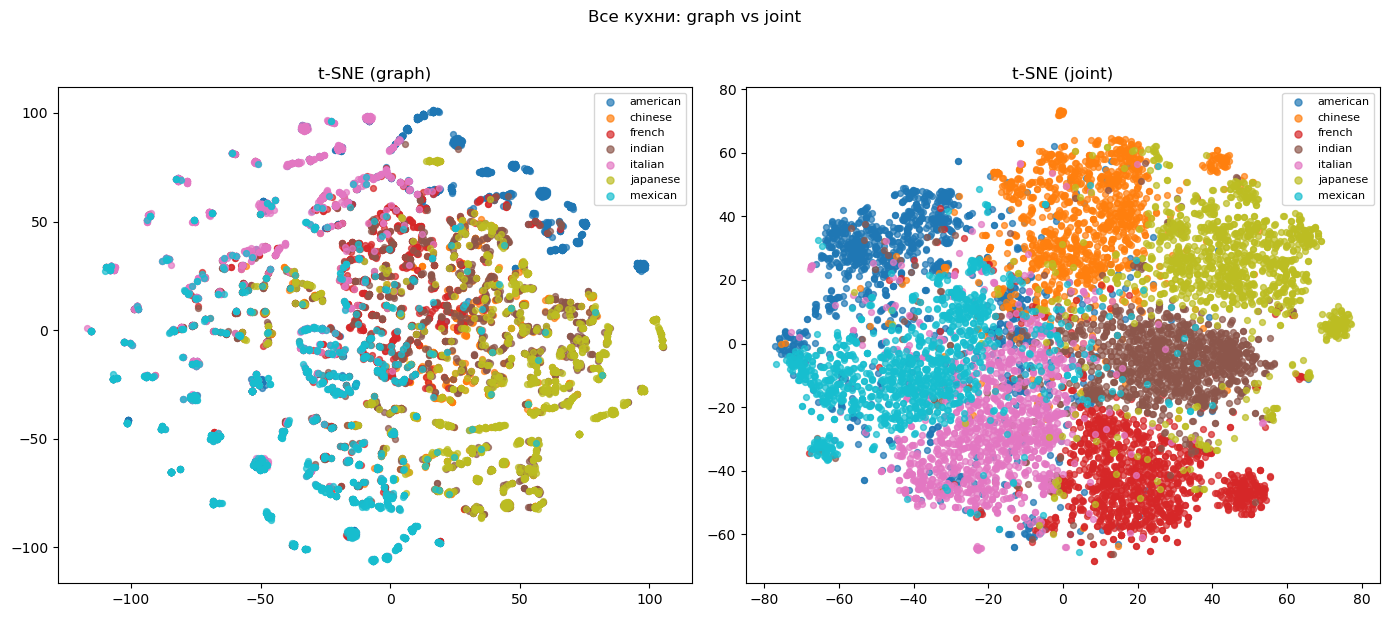


Средний pair_acc с остальными кухнями:


,graph,joint,Δ joint−graph
кухня,,,
indian,0.792,0.993,0.201
chinese,0.846,0.994,0.148
french,0.848,0.995,0.147
mexican,0.859,0.993,0.133
american,0.877,0.986,0.109
japanese,0.887,0.994,0.107
italian,0.885,0.990,0.106


In [21]:
# === Блок E: все пары кухонь — graph vs joint ===
from itertools import combinations

import importlib
import recipe_embeddings
importlib.reload(recipe_embeddings)
from recipe_embeddings import all_pair_separabilities, is_target_pair

TARGET_PAIR = ('indian', 'french')
if 'pair' not in dir() or not pair:
    pair = TARGET_PAIR if set(TARGET_PAIR) <= set(y_e) else None

cmp_reps = {k: reps[k] for k in ('graph', 'joint') if k in reps}
pair_rows = all_pair_separabilities(cmp_reps, y_e, seed=SEED)
pairs_df = pd.DataFrame(pair_rows)
pairs_df['Δ joint−graph'] = pairs_df['joint'] - pairs_df['graph']
pairs_df['целевая'] = pairs_df.apply(
    lambda r: is_target_pair(r['a'], r['b'], pair), axis=1)
pairs_df = pairs_df.sort_values('Δ joint−graph', ascending=False)

print(f'Пар кухонь: {len(pairs_df)}  |  целевая: {" / ".join(pair)}')
display(pairs_df[['pair', 'graph', 'joint', 'Δ joint−graph', 'целевая']].round(3))

# тепловая карта Δ: зелёный = joint лучше разводит пару
cuis_list = sorted(set(y_e))
idx = {c: i for i, c in enumerate(cuis_list)}
delta_mat = np.full((len(cuis_list), len(cuis_list)), np.nan)
for _, row in pairs_df.iterrows():
    i, j = idx[row['a']], idx[row['b']]
    delta_mat[i, j] = delta_mat[j, i] = row['Δ joint−graph']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(delta_mat, cmap='RdYlGn', vmin=-0.15, vmax=0.15)
ax.set_xticks(range(len(cuis_list)), cuis_list, rotation=45, ha='right')
ax.set_yticks(range(len(cuis_list)), cuis_list)
ax.set_title('Δ pair_acc (joint − graph) для каждой пары кухонь')
for i, j in combinations(range(len(cuis_list)), 2):
    if not np.isnan(delta_mat[i, j]):
        ax.text(j, i, f'{delta_mat[i, j]:+.2f}', ha='center', va='center', fontsize=8)
if pair[0] in idx and pair[1] in idx:
    for i, j in ((idx[pair[0]], idx[pair[1]]), (idx[pair[1]], idx[pair[0]])):
        ax.add_patch(plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, fill=False, edgecolor='k', lw=2))
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(OUT / 'cuisine_pair_delta.png', dpi=120)
plt.show()

# t-SNE: graph и joint рядом, все кухни одинаково видны
def _tsne_2d(X):
    return TSNE(
        n_components=2, random_state=SEED,
        perplexity=min(30, max(5, len(y_e) // 20)), init='pca',
    ).fit_transform(StandardScaler().fit_transform(np.asarray(X, float)))

palette = plt.cm.tab10(np.linspace(0, 1, len(cuis_list)))
color = {c: palette[i] for i, c in enumerate(cuis_list)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, rep_name in zip(axes, cmp_reps):
    emb2 = _tsne_2d(reps[rep_name])
    for c in cuis_list:
        m = y_e == c
        ax.scatter(emb2[m, 0], emb2[m, 1], s=18, alpha=0.7, label=c, color=color[c])
    ax.set_title(f't-SNE ({rep_name})')
    ax.legend(markerscale=1.2, fontsize=8, loc='best')
fig.suptitle('Все кухни: graph vs joint', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_graph_vs_joint.png', dpi=120)
plt.show()

# сводка по кухням: средний pair_acc со всеми остальными
avg_rows = []
for c in cuis_list:
    sub = pairs_df[(pairs_df['a'] == c) | (pairs_df['b'] == c)]
    avg_rows.append({
        'кухня': c,
        'graph': sub['graph'].mean(),
        'joint': sub['joint'].mean(),
    })
avg_delta = pd.DataFrame(avg_rows).set_index('кухня')
avg_delta['Δ joint−graph'] = avg_delta['joint'] - avg_delta['graph']
avg_delta = avg_delta.sort_values('Δ joint−graph', ascending=False)
print('\nСредний pair_acc с остальными кухнями:')
display(avg_delta.round(3))